# Fase 4 — Quatro estratégias

Relatório das estratégias de `moq.strategies`: momentum, reversão à média, par cointegrado e carry na curva DI.
Todos os retornos aqui são **provisórios**: sem custos de transação, sem remuneração do caixa (exceto no carry, que por construção fica no CDI quando desligado).
Servem para olhar o comportamento, não para decidir nada — o backtest de verdade vem na Fase 5.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import strategies

plt.rcParams["figure.figsize"] = (10, 4)

prices = pd.read_parquet(DATA / "processed" / "precos.parquet")
cdi = pd.read_parquet(DATA / "processed" / "cdi.parquet")["cdi"]
rets = prices.pct_change(fill_method=None).fillna(0.0)

print("período:", prices.index.min().date(), "→", prices.index.max().date(), "| ativos:", prices.shape[1])
print("CDI no mesmo calendário:", cdi.index.equals(prices.index))

período: 2012-01-02 → 2026-09-14 | ativos: 23
CDI no mesmo calendário: True


## O contrato

1. **O que uma estratégia devolve:** um DataFrame de pesos com o mesmo índice de datas e as mesmas colunas dos preços, sem NaN e com exposição bruta Σ|w| ≤ 1 em todo dia.
2. **O que o decorador `@lagged` garante:** ele defasa os pesos em 1 dia (o peso de hoje só usa informação até ontem) e verifica essas condições, lançando erro se alguma quebrar.
3. **Por que o defasamento é único:** ele mora só no decorador — se cada estratégia defasasse por conta própria, seria fácil esquecer (look-ahead) ou defasar duas vezes, e o `test_lagged_bloqueia_mesmo_dia` prova que ele é o que impede usar o preço do próprio dia.

In [2]:
def retorno_bruto(w):
    """Provisório. Sem custo, sem CDI no caixa. Só para olhar."""
    return (w * rets).sum(axis=1)


def turnover_anual(w):
    """Soma de |Δw| por dia, anualizada. Trocar a carteira long-only inteira custa 2."""
    return w.diff().abs().sum(axis=1).mean() * 252


def plot_patrimonio(r, nome):
    eq = pd.DataFrame({nome: (1 + r).cumprod(), "CDI": (1 + cdi).cumprod()})
    return eq.plot(logy=True, title=f"Patrimônio: {nome} vs CDI (provisório, sem custos)")

## 1. Momentum

**Intuição:** ações que mais subiram nos últimos 12 meses tendem a continuar subindo por mais algum tempo.
Compramos o top 20% pelo retorno entre t−252 e t−21 (pulando o último mês, que costuma reverter) e rebalanceamos no fim de cada mês.

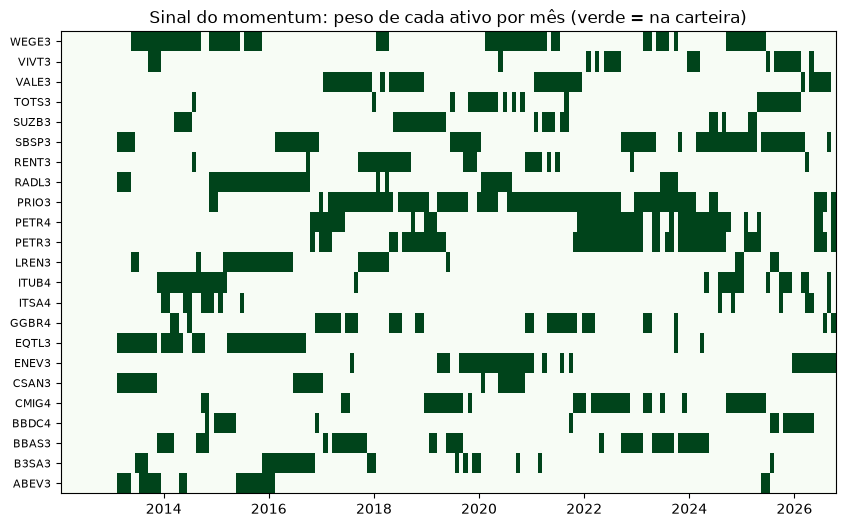

In [3]:
w_mom = strategies.momentum(prices)
r_mom = retorno_bruto(w_mom)

# sinal: quem está na carteira em cada mês
w_mes = w_mom.resample("ME").last()
fig, ax = plt.subplots(figsize=(10, 6))
ax.pcolormesh(w_mes.index, np.arange(w_mes.shape[1]), w_mes.T.to_numpy(), cmap="Greens", shading="nearest")
ax.set_yticks(np.arange(w_mes.shape[1]), w_mes.columns, fontsize=8)
ax.set_title("Sinal do momentum: peso de cada ativo por mês (verde = na carteira)");

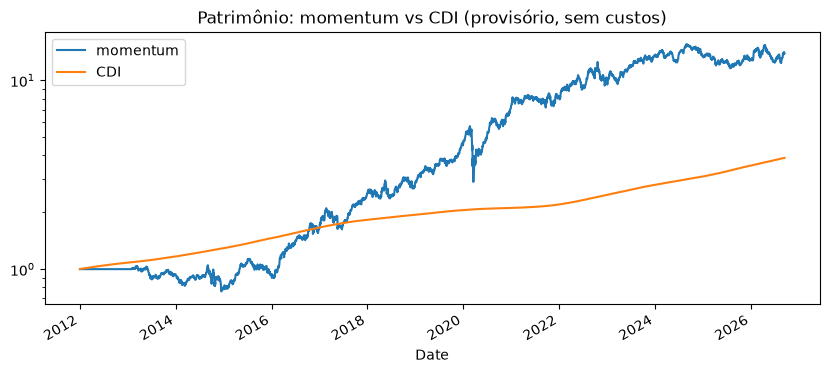

In [4]:
plot_patrimonio(r_mom, "momentum");

In [5]:
print(f"turnover anual do momentum: {turnover_anual(w_mom):.1f}")

turnover anual do momentum: 5.3


**Quando sofre.** O momentum sofre nas viradas bruscas de mercado, quando os vencedores do último ano caem juntos e os perdedores disparam na recuperação.
Como a carteira só muda uma vez por mês, ela demora a sair do que parou de funcionar.
O pior drawdown (−49%) terminou em 18/03/2020, no crash da covid, e 2014 (−15%) e 2024–2025 (perto de zero) mostram trechos sem tendência clara.
Parte do retorno alto (CAGR de ~20%) também é suspeito: o universo são 23 ações escolhidas **hoje**, então há viés de sobrevivência — ações que afundaram e saíram da bolsa nunca entram na conta.

## 2. Reversão à média

**Intuição:** quedas ou altas exageradas em poucos dias tendem a ser parcialmente desfeitas.
Olhamos o z-score do retorno de 5 dias contra a janela de 60 dias e apostamos contra quem passou de 1,5 desvios (compra quem caiu demais, vende quem subiu demais).

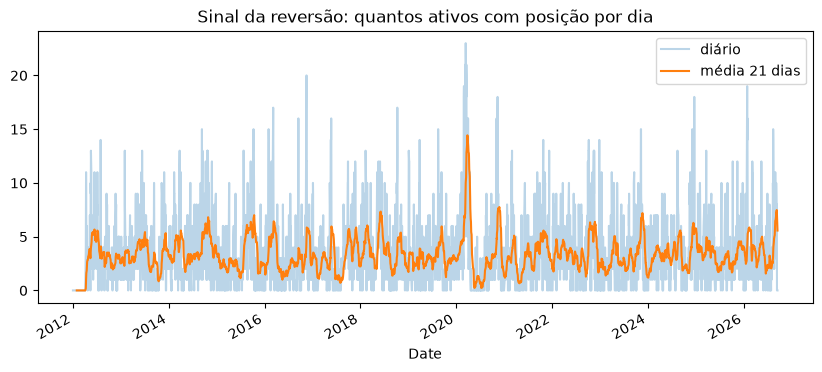

In [6]:
w_rev = strategies.mean_reversion(prices)
r_rev = retorno_bruto(w_rev)

# sinal: quantos ativos têm posição em cada dia (média de 21 dias para ler melhor)
n_sinal = (w_rev != 0).sum(axis=1)
ax = n_sinal.plot(alpha=0.3, label="diário")
n_sinal.rolling(21).mean().plot(ax=ax, label="média 21 dias")
ax.set_title("Sinal da reversão: quantos ativos com posição por dia")
ax.legend();

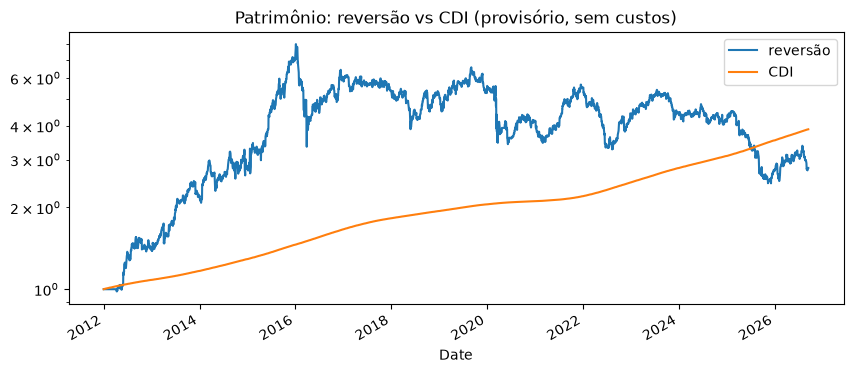

In [7]:
plot_patrimonio(r_rev, "reversão");

In [8]:
print(f"turnover anual da reversão: {turnover_anual(w_rev):.1f}")

turnover anual da reversão: 254.5


**Quando sofre.** A reversão sofre quando o movimento extremo é informação e não ruído: notícia da empresa, crise ou mudança de patamar fazem o preço continuar andando na mesma direção, e a estratégia fica apostando contra a tendência.
Foi o que aconteceu de 2016 a 2020 e em 2025 (−34%); o pior drawdown (−69%) terminou em 04/12/2025.
Os ganhos de 2012–2015 vêm muito de poucos dias extremos de PRIO3 e ENEV3, que na época eram ações pequenas e voláteis — difícil de capturar na prática.
E o turnover de ~250 por ano significa girar a carteira quase todo dia: com custos, esse retorno provavelmente some.

## 3. Par cointegrado (ITUB4 / BBDC4)

**Intuição:** dois bancos parecidos respondem aos mesmos fatores, então a distância entre eles (o spread) deveria voltar ao normal.
Entramos quando o z-score do spread passa de ±2 (vendendo o caro, comprando o barato), saímos quando volta para dentro de ±0,5 e paramos a perda se passar de ±4.

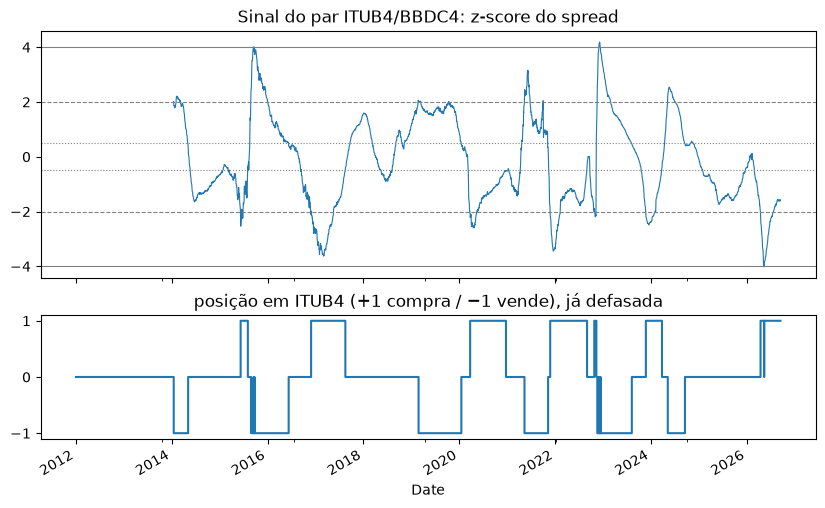

In [9]:
a, b = "ITUB4", "BBDC4"
entry, exit_, stop = 2.0, 0.5, 4.0
w_par = strategies.pairs(prices, a=a, b=b, entry=entry, exit=exit_, stop=stop)
r_par = retorno_bruto(w_par)

# o mesmo z-score que strategies.pairs calcula por dentro, para desenhar o sinal
window = 252
la, lb = np.log(prices[a]), np.log(prices[b])
beta = la.rolling(window).cov(lb) / lb.rolling(window).var(ddof=1)
spread = la - beta * lb
z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std(ddof=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
z.plot(ax=ax1, lw=0.8, title=f"Sinal do par {a}/{b}: z-score do spread")
for nivel, estilo in [(entry, "--"), (exit_, ":"), (stop, "-")]:
    ax1.axhline(nivel, color="gray", ls=estilo, lw=0.8)
    ax1.axhline(-nivel, color="gray", ls=estilo, lw=0.8)
np.sign(w_par[a]).plot(ax=ax2, drawstyle="steps-post", title=f"posição em {a} (+1 compra / −1 vende), já defasada");

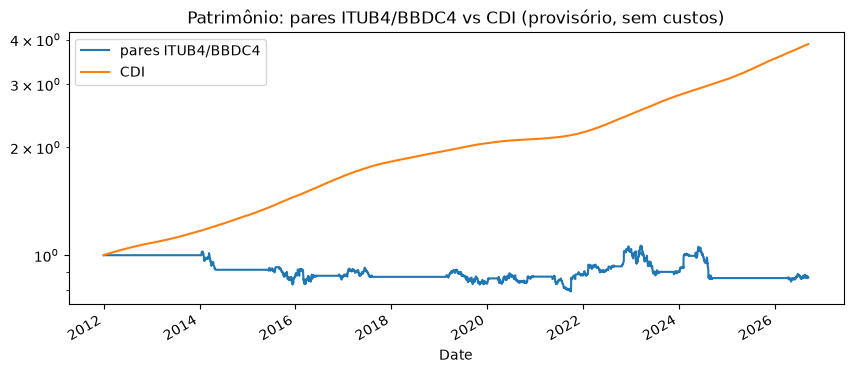

In [10]:
plot_patrimonio(r_par, f"pares {a}/{b}");

In [11]:
print(f"turnover anual do par: {turnover_anual(w_par):.1f}")
print(f"dias com posição: {(w_par.abs().sum(axis=1) > 0).mean():.0%}")

turnover anual do par: 3.0
dias com posição: 46%


**Quando sofre.** O par sofre quando a relação entre os dois ativos muda de vez: o spread abre e não volta, a estratégia entra esperando convergência e sai no stop.
Aqui o problema é de origem: ITUB4/BBDC4 **não passou** no teste de cointegração (p = 0,43, ver o registro de escolhas), então não havia garantia de que o spread voltasse.
O resultado acompanha: CAGR perto de zero, pior drawdown de −23% até 01/10/2021 e −12% em 2023, com a posição fora do mercado em mais da metade dos dias.

## 4. Carry na curva DI

**Intuição:** quando a taxa pré de 1 ano paga bem mais que o CDI, vale travar a taxa pré e ganhar essa inclinação.
Ficamos no título pré quando a inclinação (pré − CDI anual) passa da média móvel de 252 dias + 1 desvio; nos outros dias ficamos no CDI.

> ⚠️ **Curva DI simulada.** Ainda não há fonte de dados para a taxa pré de 1 ano: `y_1y` abaixo é um passeio aleatório (começa em 10% a.a., passos diários N(0; 0,15 p.p.), limitado entre 2% e 25%, semente 1).
> O código da estratégia está pronto e testado, mas **os números desta seção não dizem nada sobre o mercado** — só mostram que a mecânica funciona.

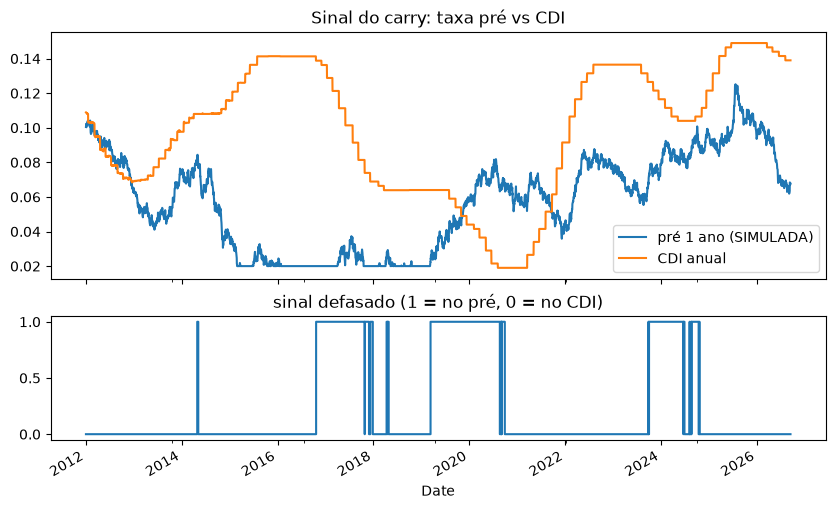

In [12]:
rng = np.random.default_rng(1)
y_1y = pd.Series(0.10 + np.cumsum(rng.normal(0, 0.0015, len(prices))), index=prices.index).clip(0.02, 0.25)

r_carry = strategies.carry_returns(y_1y, cdi)
sig_carry = strategies.carry_signal(y_1y, cdi).shift(1).fillna(0.0)  # a mesma defasagem que carry_returns aplica

# 6 feriados de 2017 têm linha nos preços e CDI = 0; só no gráfico repetimos a taxa do dia anterior
cdi_anual = ((1 + cdi) ** 252 - 1).where(cdi > 0).ffill()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
pd.DataFrame({"pré 1 ano (SIMULADA)": y_1y, "CDI anual": cdi_anual}).plot(ax=ax1, title="Sinal do carry: taxa pré vs CDI")
sig_carry.plot(ax=ax2, drawstyle="steps-post", title="sinal defasado (1 = no pré, 0 = no CDI)");

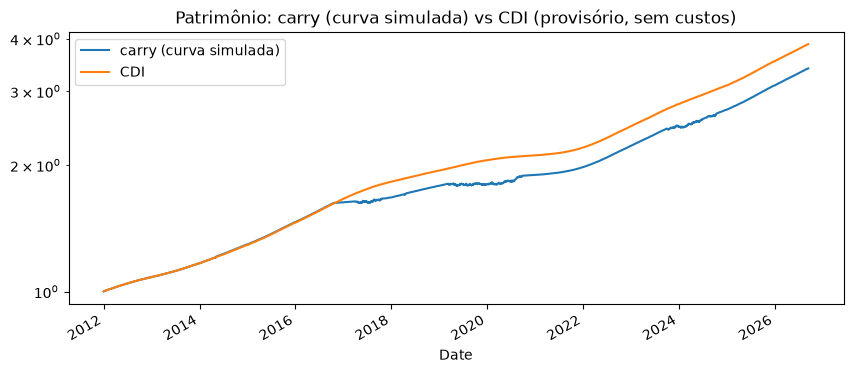

In [13]:
plot_patrimonio(r_carry, "carry (curva simulada)");

In [14]:
# aqui o "peso" é 0 ou 1 no pré: cada troca entre CDI e pré conta 1
print(f"turnover anual do carry: {sig_carry.diff().abs().mean() * 252:.1f} trocas por ano")
print(f"dias no pré: {sig_carry.mean():.0%}")

turnover anual do carry: 2.3 trocas por ano
dias no pré: 25%


**Quando sofre.** Com dados reais, o carry sofre quando os juros sobem de surpresa enquanto a estratégia está no pré: o título é marcado a mercado para baixo e a perda come o ganho de inclinação de vários meses.
Ciclos de alta rápida da Selic, como 2015 e 2021, seriam os momentos a observar — e o sinal por média móvel tende a ligar justamente quando a inclinação já está alta, perto do topo dos juros.
Com a curva simulada, o drawdown de ~1% e o retorno parecido com o CDI não significam nada; esse parágrafo precisa ser revisto quando entrar a série real.

## Tabela-resumo provisória

> ⚠️ **Sem custos de transação** e sem remuneração do caixa. Reversão e pares têm turnover alto ou muitos dias parados, então os números de verdade (Fase 5) devem piorar.
> O carry usa a curva DI **simulada**.

- **Sharpe:** média ÷ desvio dos retornos diários × √252. Para momentum e carry, que ocupam o lugar do caixa, sobre o excesso ao CDI; reversão e pares são long-short (autofinanciados), então sem subtrair o CDI.
- **Max drawdown:** maior queda do patrimônio desde o pico anterior.
- **Turnover:** soma de |Δw| por ano (no carry, trocas entre CDI e pré por ano).

In [15]:
def sharpe(r):
    return r.mean() / r.std() * np.sqrt(252)


def max_drawdown(r):
    eq = (1 + r).cumprod()
    return (eq / eq.cummax() - 1).min()


resumo = pd.DataFrame({
    "Sharpe": [sharpe(r_mom - cdi), sharpe(r_rev), sharpe(r_par), sharpe(r_carry - cdi)],
    "base do Sharpe": ["excesso ao CDI", "long-short", "long-short", "excesso ao CDI"],
    "Max drawdown": [max_drawdown(r) for r in (r_mom, r_rev, r_par, r_carry)],
    "Turnover/ano": [turnover_anual(w_mom), turnover_anual(w_rev), turnover_anual(w_par),
                     sig_carry.diff().abs().mean() * 252],
}, index=["momentum", "reversão", "pares", "carry (simulado)"])

resumo.style.format({"Sharpe": "{:.2f}", "Max drawdown": "{:.0%}", "Turnover/ano": "{:.1f}"})

,Sharpe,base do Sharpe,Max drawdown,Turnover/ano
momentum,0.48,excesso ao CDI,-49%,5.3
reversão,0.39,long-short,-69%,254.5
pares,-0.08,long-short,-23%,3.0
carry (simulado),-0.86,excesso ao CDI,-1%,2.3


## Correlação entre as estratégias

Esta tabela é a tese do projeto: se as correlações forem baixas (|ρ| < 0,3), combinar as quatro na Fase 6 deve reduzir o risco de verdade.

In [16]:
R = pd.DataFrame({"momentum": r_mom, "reversao": r_rev, "pares": r_par, "carry": r_carry}).dropna()
R.corr().round(2)

,momentum,reversao,pares,carry
momentum,1.00,0.14,-0.11,-0.01
reversao,0.14,1.00,0.01,-0.00
pares,-0.11,0.01,1.00,-0.03
carry,-0.01,-0.00,-0.03,1.00


**O que eu vejo.** Todas as correlações ficam bem abaixo de 0,3 — a maior em módulo é momentum × reversão (0,14), e as outras estão entre −0,11 e 0,01.
À primeira vista a tese se sustenta, mas há três ressalvas antes de comemorar:

- **Carry ≈ 0 por construção:** a curva simulada é independente das ações, então a correlação zero dele não prova nada. Precisa ser refeita com a série real.
- **Pares fica parado em mais da metade dos dias:** dias com retorno zero puxam a correlação para zero mecanicamente. Vale olhar a correlação só nos dias com posição.
- **Sem custos:** a reversão paga muito custo, o que muda o nível do retorno (e o Sharpe), mas não deve mudar muito a correlação.

Momentum × pares negativo (−0,11) é o dado mais interessante: uma estratégia de tendência e uma de convergência tendem a ganhar em momentos diferentes.

## Registro de escolhas

### Pares testados

Teste de cointegração de Engle-Granger (`statsmodels.tsa.stattools.coint`) nos log-preços, com treino de 2012 a 2017:

In [17]:
treino = prices.loc["2012":"2017"]
candidatos = [("ITUB4", "BBDC4"), ("PETR3", "PETR4"), ("ITSA4", "ITUB4"), ("CMIG4", "SBSP3")]
testes = pd.DataFrame(
    [(f"{x}/{y}", coint(np.log(treino[x]), np.log(treino[y]))[1]) for x, y in candidatos],
    columns=["par", "p-valor"],
).set_index("par")
testes["cointegrado (p < 0,05)?"] = np.where(testes["p-valor"] < 0.05, "sim", "não")
testes.round(3)

,p-valor,"cointegrado (p < 0,05)?"
par,,
ITUB4/BBDC4,0.426,não
PETR3/PETR4,0.274,não
ITSA4/ITUB4,0.085,não
CMIG4/SBSP3,0.571,não


- **Nenhum par passou** a 5%. O mais próximo foi ITSA4/ITUB4 (p = 0,085).
- **Usei ITUB4/BBDC4 mesmo assim** (p = 0,43), porque é o par do roteiro — o objetivo desta fase é a mecânica, não escolher o melhor par. O resultado fraco da seção 3 é coerente com isso.
- No notebook 05 havia um quinto candidato, `ITUB4/BBC4`, com erro de digitação (BBC4 não existe) e por isso ignorado; o par correto, ITUB4/BBDC4, já está na lista.
- Cuidado para a Fase 5: testar vários pares e ficar com o menor p-valor é teste múltiplo, e o treino (2012–2017) está dentro do período do backtest.

### Fonte da curva DI

**Nenhuma ainda — a curva é simulada** (passeio aleatório, semente 1, descrito na seção 4).
Tentei as séries de swap DI × pré do SGS do Banco Central e o Ipeadata, sem achar a série diária de 1 ano.
Antes da Fase 5 é preciso trocar por dado real (candidatas: contratos DI1 da B3 ou a ETTJ da ANBIMA) e refazer a seção 4, a tabela e a correlação.

### Parâmetros experimentados

Os do roteiro, sem nenhuma busca — a grade de busca vem na Fase 5:

| estratégia | parâmetros |
|---|---|
| momentum | `lookback=252`, `skip=21`, `top=0.2`, rebalanceamento mensal (`"ME"`) |
| reversão | `short=5`, `long=60`, `threshold=1.5` |
| pares | `window=252`, `entry=2.0`, `exit=0.5`, `stop=4.0`, par ITUB4/BBDC4 |
| carry | `window=252`, `k=1.0` |

A única "busca" foi entre os 4 pares acima, e ela não mudou a escolha.